# Simulate populations with spontaneus creation
## Part 4

In the previous part, we explored some equations and functions that allow us to calculate the expected equilibrium of the simluation given `birth_rate` ($B$) and `death_chance` ($d$), and the expected change in population ($\Delta P$) given the current population. We are now interested in the 'age' of protocells in the population when they expire (die). So far we have been discarding the expired population in our simulation, so in order to analyze this population demographic, we will need to update the `environment` class with an additional `mortuary` variable to keep track. 

In [1]:
# Import required modules
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction
import random
import collections

## Update the Simulation with `mortuary`

Remember that each protocell is represented by the `entity` object, which has just one property, `period`, to keep track of how many time steps the `entity` (protocell) has survived in the current simulation.

The new `mortuary` variable is a [`collections.Counter`][1] object, which we use to conveniently and efficiently store the frequencies with which protocells expire at different periods (ages). In layman terms, once a protocell expires it is moved to the mortuary and it's age is tallied.

[1]: https://docs.python.org/2/library/collections.html#collections.Counter

In [7]:
def trial(chance):
    """ Returns the boolean outcome of a trial given it's chance of success."""

    return random.random() <= chance


class entity():
    """ The entity object represents a live entity."""
    
    def __init__(self):
        self.period = 0
    
    def __repr__(self):
        return str(self.period)

    def __call__(self):
        self.period += 1
        return self


class environment():
    """ The environment tracks the population and parameters of the simulation."""

    def __init__(self, birth_rate, death_chance):
        self.birth_rate = birth_rate
        self.death_chance = death_chance
        self.population = []
        self.history = []
        self.mortuary = collections.Counter()

    def __call__(self):

        survive, expire = [], []
        for e in self.population:
            if trial(self.death_chance):
               expire.append(e.period) 
            else:
                survive.append(e())
        
        self.population = survive
        self.population.append(entity())
        self.mortuary.update(expire)
        self.history.append(len(self.population))

## Run the Simulation for 1,000 Periods
This time, we will run the simulation once for 1,000 time steps and print out three graphs instead of one - the line graph that we are already familiar with, a frequency histogram showing the frequency at which the protocells expire in different age groups (bins) in the simulated population, and a frequency plot showing the same data but with each age tallied individually (ungrouped).

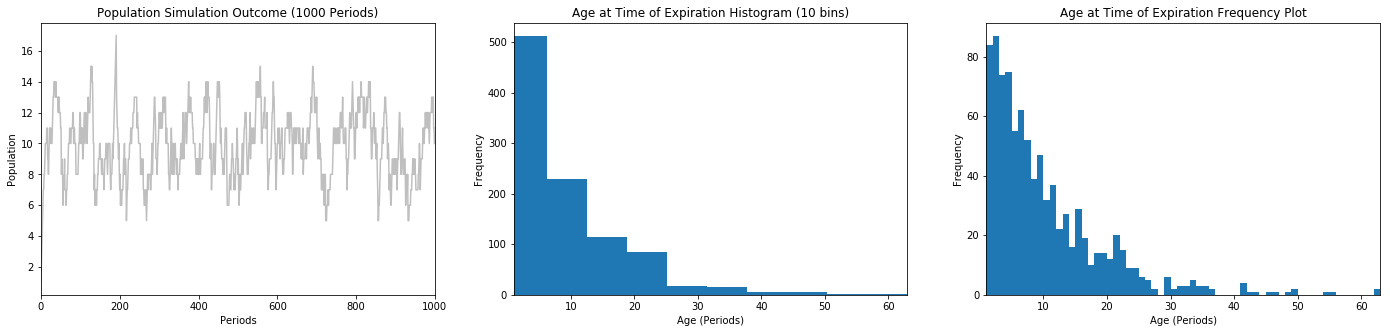

In [8]:
def run_sim(birth_rate, death_chance, n_periods):
    """ Run simulation of environment n times and plot the result"""

    # Set up plots.
    fig, ax = plt.subplots(1, 3, figsize=(24,5))

    # Run simulation n times.
    env = environment(birth_rate, death_chance)
    for period in range(0, n_periods):
        env()
    history = env.history
    mortuary = tuple(env.mortuary.elements())

    # Set plot properties.
    ax[0].set(
        title=f"Population Simulation Outcome ({n_periods} Periods)",
        xlabel="Periods",
        ylabel="Population",
        xlim=(0, n_periods)
    )
    ax[1].set(
        title=f"Age at Time of Expiration Histogram (10 bins)",
        xlabel="Age (Periods)",
        ylabel="Frequency",
        xlim=(1, max(mortuary))
    )
    ax[2].set(
        title=f"Age at Time of Expiration Frequency Plot",
        xlabel="Age (Periods)",
        ylabel="Frequency",
        xlim=(1, max(mortuary))
    )

    # Line graph of population over time.
    ax[0].plot(history, color=[.5, .5, .5, .5])

    # Frequency bar chart of population age at expiration of entity.
    ax[1].hist(mortuary, 10)

    # Frequency plot of population age at expiration of entity.
    ax[2].hist(mortuary, max(mortuary))

    return mortuary

# Run the simulation n times.
mortuary = run_sim(1, .1, 1000)


## Conclusion

The Histogram shows the age of expiration of protocells grouped into 10 bins, while the Frequency Plot shows each individual expiration age ungrouped. On both plots, the x-axis is the age of the protocells, while the y-axis is the number of protocells that expired at that age. Note the general trend of the distribution of the ages at which protocells expire - most expire at low age, then there is a sharp decrease which begins to flatten out at around age 30, and gradually fewer cells survive longer until there are just one or two representatives of the oldest age reached during the simulation. In fact, we are observing a well known phenomena that is the focus of [survival analysis][1]. 

You will also note that the Frequency Plot in particular shows some variation in the frequency at which cells die at different ages. With a larger sample size, this coarse texture will begin to soften into a smooth line. In the next section, we will improve our empirical data by running the simulation for much longer.

[1]: https://en.wikipedia.org/wiki/Survival_analysis